# 🎬 Lecture Agent Studio v3

v2에서 발견된 문제점(스크립트 반복 표현, 중복 코드, FFmpeg 경로 불일치 등)을 전면 개선한 버전입니다.

## 📦 Cell 1. 통합 Import & 환경 설정

v2에서 파일 곳곳에 흩어져 있던 import문과 환경변수를 **한 곳에 통합**했습니다.

In [7]:
# ============================================================
# 📦 통합 Import & 환경 설정 (v3 개선: 중복 제거, 한 곳에 집중)
# ============================================================
import os, re, textwrap, subprocess, json, base64, mimetypes, platform, shutil, time
from pathlib import Path
from typing import List, Dict, Optional, TypedDict, Any
from difflib import SequenceMatcher
from urllib.parse import urlparse

# PPT 파싱
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE, PP_PLACEHOLDER

# OpenAI
from openai import OpenAI

# LangChain
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 검색 (RAG)
from tavily import TavilyClient
from langchain_community.tools.tavily_search import TavilySearchResults

# Jupyter 표시용
from IPython.display import Audio, Video, display

# ============================================================
# 🔑 환경변수 로드 (.env 파일에서 자동으로 읽어옵니다)
# ============================================================
from dotenv import load_dotenv
load_dotenv()

LLM_MODEL = os.getenv("LLM_MODEL", "gpt-4o")
TTS_MODEL = os.getenv("TTS_MODEL", "tts-1")
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# ============================================================
# 🎬 FFmpeg 경로 통일 (v3 개선: 모든 노드에서 동일 변수 사용)
# ============================================================
FFMPEG_CMD = "ffmpeg"
FFPROBE_CMD = "ffprobe"
if platform.system() == "Windows":
    winget_ffmpeg = r"C:\Users\USER\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1.2-full_build\bin\ffmpeg.exe"
    winget_ffprobe = r"C:\Users\USER\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1.2-full_build\bin\ffprobe.exe"
    if os.path.exists(winget_ffmpeg):
        FFMPEG_CMD = winget_ffmpeg
    if os.path.exists(winget_ffprobe):
        FFPROBE_CMD = winget_ffprobe

print(f"✅ 환경 설정 완료")
print(f"   LLM: {LLM_MODEL} | TTS: {TTS_MODEL}")
print(f"   FFmpeg: {FFMPEG_CMD}")

✅ 환경 설정 완료
   LLM: gpt-4o | TTS: gpt-4o-mini-tts
   FFmpeg: C:\Users\USER\AppData\Local\Microsoft\WinGet\Packages\Gyan.FFmpeg_Microsoft.Winget.Source_8wekyb3d8bbwe\ffmpeg-8.1.2-full_build\bin\ffmpeg.exe


## 🔧 Cell 2. 유틸리티 함수

v2에서 2번 정의되어 있던 `ffprobe_duration` 등을 **1곳에 통합**했습니다.

In [8]:
# ============================================================
# 🔧 유틸리티 함수 (v3 개선: 중복 제거, 통합)
# ============================================================

def clean_text(s):
    """공백/줄바꿈 정리"""
    return re.sub(r"\s+", " ", s).strip()

def split_sents(t: str) -> List[str]:
    """문장 단위 분리"""
    parts = re.split(r'([.?!])', t)
    merged = []
    for i in range(0, len(parts)-1, 2):
        sent = (parts[i] + parts[i+1]).strip()
        if sent:
            merged.append(sent)
    if len(parts) % 2 == 1 and parts[-1].strip():
        merged.append(parts[-1].strip())
    return [s for s in merged if s]

def ffprobe_duration(path: str) -> float:
    """오디오/비디오 파일의 재생 시간(초) 반환"""
    out = subprocess.check_output([
        FFPROBE_CMD, "-v", "error", "-show_entries", "format=duration",
        "-of", "default=noprint_wrappers=1:nokey=1", path
    ]).decode().strip()
    return float(out)

def img_to_data_url(path: str) -> str:
    """이미지를 base64 data URL로 변환"""
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

def export_slide_as_png(state: dict, dpi: int = 220) -> dict:
    """PPT 슬라이드 1장을 PNG 이미지로 변환"""
    work_dir = Path(state["work_dir"]).expanduser().resolve()
    work_dir.mkdir(parents=True, exist_ok=True)
    pptx_path = Path(state["pptx_path"]).expanduser().resolve()
    if not pptx_path.exists():
        raise FileNotFoundError(f"PPTX 없음: {pptx_path}")
    idx = int(state.get("slide_index", 0))
    page_no = idx + 1
    out_prefix = work_dir / "slide_img"
    png_path = work_dir / f"{out_prefix.stem}-{page_no}.png"
    env = os.environ.copy()
    env.update({"LANG": "ko_KR.UTF-8", "LC_ALL": "ko_KR.UTF-8"})
    soffice_cmd = "soffice"
    if platform.system() == "Windows":
        if os.path.exists(r"C:\Program Files\LibreOffice\program\soffice.exe"):
            soffice_cmd = r"C:\Program Files\LibreOffice\program\soffice.exe"
    pdf_path = work_dir / f"{pptx_path.stem}.pdf"
    if not pdf_path.exists():
        lo_cmd = [soffice_cmd, "--headless", "--convert-to", "pdf:impress_pdf_Export", "--outdir", str(work_dir), str(pptx_path)]
        if platform.system() != "Windows":
            lo_cmd.insert(2, "-env:UserInstallation=file:///tmp/lo_profile")
        res_pdf = subprocess.run(lo_cmd, capture_output=True, text=True, env=env)
        if res_pdf.returncode != 0:
            raise RuntimeError("PPTX → PDF 변환 실패")
    ppm_cmd = ["pdftoppm", "-f", str(page_no), "-l", str(page_no), "-png", "-r", str(dpi), str(pdf_path), str(out_prefix)]
    subprocess.run(ppm_cmd, capture_output=True, text=True, env=env)
    if png_path.exists():
        state["slide_image"] = str(png_path)
    else:
        print(f"⚠️ 슬라이드 {page_no} PNG 변환 실패")
        state["slide_image"] = ""
    return state

print("✅ 유틸리티 함수 로드 완료")

✅ 유틸리티 함수 로드 완료


## 📋 Cell 3. State 정의

v3에서 추가된 필드: `notes`(발표자 노트), `used_expressions`(반복 방지용 표현 추적)

In [9]:
# ============================================================
# 📋 State 정의 (v3 개선: notes, used_expressions 추가)
# ============================================================

class State(TypedDict, total=False):
    # 입력/기본
    pptx_path: str
    work_dir: str
    prompt: Dict
    slide_index: int
    total_slides: int

    # 추출 산출물
    titles: List[str]
    texts: List[str]
    notes: List[str]              # ⭐ v3 추가: 발표자 노트
    tables: List[List[List[str]]]
    images: List[str]
    slide_image: List[str]
    external_content: Dict[str, List[Dict[str, str]]]
    shape_texts: List[List[str]]
    links: List[List[str]]

    # 생성 산출물
    page_content: str
    script: str
    all_scripts: List[str]
    used_expressions: List[str]   # ⭐ v3 추가: 반복 방지용

    # 미디어 산출물
    audio: str
    video_path: str
    video_paths: List[str]
    final_video: str

print("✅ State 정의 완료")

✅ State 정의 완료


## 🔍 Cell 4. Node 1: PPT 파싱 (`node_parse_all`)

**v3 개선점**: 발표자 노트(Notes) 추출 추가

In [10]:
def node_parse_all(state: State) -> State:
    pptx_path = state["pptx_path"]
    work_dir = state.get("work_dir", "./")

    base_dir = Path(work_dir).expanduser().resolve()
    slides_dir = base_dir / "slides"
    media_dir = base_dir / "media"
    slides_dir.mkdir(parents=True, exist_ok=True)
    media_dir.mkdir(parents=True, exist_ok=True)

    if not os.path.exists(pptx_path):
        print(f"❌ 오류: '{pptx_path}' 파일이 존재하지 않습니다.")
        return state

    prs = Presentation(pptx_path)
    slide_count = len(prs.slides)
    print(f"총 {slide_count}장의 슬라이드를 처리합니다.")

    titles_list, texts_list, notes_list = [], [], []
    tables_list, images_list, snapshots_list = [], [], []
    shape_texts_list, links_list = [], []
    url_pattern = r"https?://[^\s]+"

    for slide_idx, slide in enumerate(prs.slides):
        print(f"\n=== {slide_idx+1}번째 슬라이드 처리 중 ===")

        # 1) PNG 스냅샷 생성
        slide_state = {"pptx_path": pptx_path, "work_dir": str(slides_dir), "slide_index": slide_idx}
        snapshot_path = ""
        try:
            slide_state = export_slide_as_png(slide_state)
            src_png = slide_state.get("slide_image", "")
            dst_png = slides_dir / f"slide_{slide_idx+1}.png"
            if src_png and os.path.exists(src_png):
                os.replace(src_png, dst_png)
                snapshot_path = str(dst_png)
        except Exception as e:
            print(f"  ⚠️ PNG 변환 실패 (텍스트 추출은 계속): {e}")

        # ⭐ v3 추가: 발표자 노트 추출
        slide_note = ""
        try:
            if slide.has_notes_slide:
                notes_tf = slide.notes_slide.notes_text_frame
                if notes_tf and notes_tf.text.strip():
                    slide_note = notes_tf.text.strip()
        except Exception:
            pass

        slide_title, body_texts, shape_texts = "", [], []
        slide_tables, slide_images = [], []
        slide_links = set()

        # 차트 데이터 추출
        for sh in slide.shapes:
            if sh.has_chart:
                try:
                    chart = sh.chart
                    chart_data = ["\n[📊 차트 데이터]"]
                    if chart.has_title and chart.chart_title.has_text_frame:
                        chart_data.append(f"차트 제목: {chart.chart_title.text_frame.text}")
                    series_names = [s.name for s in chart.series]
                    chart_data.append("항목 | " + " | ".join(series_names))
                    if chart.plots:
                        plot = chart.plots[0]
                        categories = [c.label for c in plot.categories]
                        for i, cat in enumerate(categories):
                            row_vals = [str(cat)]
                            for s in chart.series:
                                val = s.values[i] if i < len(s.values) else ""
                                row_vals.append(str(val))
                            chart_data.append(" | ".join(row_vals))
                    body_texts.append("\n".join(chart_data))
                except Exception as e:
                    print(f"  ⚠️ 차트 데이터 추출 실패: {e}")

        # 제목 추출
        for sh in slide.shapes:
            try:
                if sh.is_placeholder and sh.placeholder_format.type == PP_PLACEHOLDER.TITLE:
                    if sh.has_text_frame and sh.text.strip():
                        slide_title = sh.text.strip()
            except:
                pass

        # 도형 텍스트
        def collect_shape_texts(shape):
            if shape.shape_type == MSO_SHAPE_TYPE.GROUP:
                for sub in shape.shapes:
                    collect_shape_texts(sub)
                return
            if shape.shape_type == MSO_SHAPE_TYPE.AUTO_SHAPE and shape.has_text_frame:
                t = shape.text_frame.text.strip()
                if t:
                    shape_texts.append(t)
        for sh in slide.shapes:
            collect_shape_texts(sh)

        # 링크 추출
        for sh in slide.shapes:
            if sh.has_text_frame:
                for p in sh.text_frame.paragraphs:
                    runs_text = "".join(r.text for r in p.runs)
                    found = re.findall(url_pattern, runs_text)
                    if found:
                        slide_links.update(found)
            try:
                if hasattr(sh, "click_action") and sh.click_action.hyperlink.address:
                    slide_links.add(sh.click_action.hyperlink.address)
            except:
                pass

        # 본문 텍스트 (제목/도형/링크 제외)
        for sh in slide.shapes:
            if not sh.has_text_frame:
                continue
            try:
                if sh.is_placeholder and sh.placeholder_format.type == PP_PLACEHOLDER.TITLE:
                    continue
            except:
                pass
            for p in sh.text_frame.paragraphs:
                txt = "".join(r.text for r in p.runs).strip()
                if not txt or txt in shape_texts or re.search(url_pattern, txt):
                    continue
                body_texts.append(txt)

        # 표 추출
        for sh in slide.shapes:
            if sh.shape_type == MSO_SHAPE_TYPE.TABLE:
                tbl = [[cell.text.strip() for cell in row.cells] for row in sh.table.rows]
                slide_tables.append(tbl)

        # 이미지 추출 (그룹/숨겨진 이미지 포함)
        def extract_images_from_shape(shape, img_list):
            if shape.shape_type == MSO_SHAPE_TYPE.GROUP:
                for sub_shape in shape.shapes:
                    extract_images_from_shape(sub_shape, img_list)
                return
            if hasattr(shape, "image"):
                try:
                    ext = shape.image.ext
                except:
                    ext = "png"
                img_name = f"slide{slide_idx+1}_img_{len(img_list)+1}.{ext}"
                img_path = media_dir / img_name
                with open(img_path, "wb") as f:
                    f.write(shape.image.blob)
                img_list.append(str(img_path))
        for sh in slide.shapes:
            extract_images_from_shape(sh, slide_images)

        # 리스트에 저장
        titles_list.append(slide_title)
        texts_list.append("\n".join(body_texts).strip())
        notes_list.append(slide_note)
        tables_list.append(slide_tables)
        images_list.append(slide_images)
        snapshots_list.append(snapshot_path)
        shape_texts_list.append(list(dict.fromkeys(shape_texts)))
        links_list.append(list(slide_links))

        print(f"  → 제목:{slide_title}, 본문:{len(body_texts)}, 노트:{'있음' if slide_note else '없음'}, 표:{len(slide_tables)}, 이미지:{len(slide_images)}")

    state["total_slides"] = slide_count
    state["titles"] = titles_list
    state["texts"] = texts_list
    state["notes"] = notes_list
    state["tables"] = tables_list
    state["images"] = images_list
    state["slide_image"] = snapshots_list
    state["shape_texts"] = shape_texts_list
    state["links"] = links_list
    return state

print("✅ node_parse_all 정의 완료")

✅ node_parse_all 정의 완료


## 🧪 Cell 5. [테스트] node_parse_all

In [11]:
test_state = {
    "pptx_path": "../data/sample.pptx",
    "work_dir": "../output_v3_test"
}
result_state = node_parse_all(test_state)

print("\n" + "="*50)
print("🎯 [첫 번째 슬라이드 추출 결과]")
print("="*50)
idx = 0
print(f"▶ 제목: {result_state['titles'][idx]}")
print(f"▶ 본문: {result_state['texts'][idx][:200]}...")
print(f"▶ 노트: {result_state['notes'][idx][:200] if result_state['notes'][idx] else '(없음)'}")
print(f"▶ 표: {len(result_state['tables'][idx])}개")
print(f"▶ 이미지: {len(result_state['images'][idx])}개")

총 3장의 슬라이드를 처리합니다.

=== 1번째 슬라이드 처리 중 ===
  → 제목:모델 성능 모니터링, 본문:12, 노트:없음, 표:0, 이미지:1

=== 2번째 슬라이드 처리 중 ===
  → 제목:ML 모델에 영향을 줄 수 있는 요인, 본문:3, 노트:있음, 표:0, 이미지:1

=== 3번째 슬라이드 처리 중 ===
  → 제목:모델 모니터링 아키텍처, 본문:3, 노트:없음, 표:1, 이미지:0

🎯 [첫 번째 슬라이드 추출 결과]
▶ 제목: 모델 성능 모니터링
▶ 본문: 모델 모니터링
프로덕션 환경에서 ML 모델의 성능 및 동작을 지속적으로 추적, 분석, 평가하는 프로세스
필요성 : 모델은 배포 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출됨
주요 리스크
데이터/컨셉 드리프트
데이터 품질 문제
적대적 공격(예: prompt injection)
연결된 앞 단계의 모델 오류 전파
모니터링 목표
문제 조기 ...
▶ 노트: (없음)
▶ 표: 0개
▶ 이미지: 1개


## 🔍 Cell 6. 검색 점수 함수 + Tavily 검색

v3 개선: 불필요한 `print(results_sorted)` 디버그 로그 제거

In [12]:
# ============================================================
# 🔍 검색 점수 계산 함수 + Tavily 검색
# ============================================================

DOMAIN_TRUST = {
    "microsoft.com": 0.95, "learn.microsoft.com": 0.98,
    "docs.python.org": 0.98, "wikipedia.org": 0.9,
    "mozilla.org": 0.9, "naver.com": 0.8,
    "cloud.naver.com": 0.9, "kakao.com": 0.8,
}

EXCLUDE_DOMAINS = [
    "blog.naver.com", "m.blog.naver.com", "tistory.com",
    "brunch.co.kr", "medium.com", "velog.io",
    "kin.naver.com", "reddit.com", "youtube.com"
]

def _norm_text(s: str) -> str:
    s = (s or "").lower()
    s = re.sub(r"[^가-힣a-z0-9\s]", " ", s)
    return re.sub(r"\s+", " ", s).strip()

def similarity_score(query: str, snippet: str) -> float:
    q, t = _norm_text(query), _norm_text(snippet)
    if not q or not t:
        return 0.0
    q_tokens, t_tokens = set(q.split()), set(t.split())
    overlap = len(q_tokens & t_tokens) / len(q_tokens) if q_tokens and t_tokens else 0.0
    seq_sim = SequenceMatcher(None, q, t).ratio()
    return (overlap + seq_sim) / 2.0

def domain_score(domain: str) -> float:
    domain = (domain or "").lower()
    for key, score in DOMAIN_TRUST.items():
        if key in domain:
            return score
    if not domain:
        return 0.4
    return max(0.45, min(0.5 + min(len(domain) / 50.0, 0.15), 0.65))

def content_score(snippet: str, max_len: int = 400) -> float:
    if not snippet:
        return 0.0
    return max(0.1, min(len(snippet) / max_len, 1.0))

def tavily_search(title: str, num: int = 4) -> list[dict]:
    query = f"{title} " + " ".join([f"-site:{d}" for d in EXCLUDE_DOMAINS])
    candidate_k = max(num * 3, num + 2)
    res_tool = TavilySearchResults(
        max_results=candidate_k, search_depth="basic", topic="general",
        exclude_domains=EXCLUDE_DOMAINS, include_answer=False, include_raw_content=False,
    )
    data = res_tool.invoke(query) or []
    results, seen_urls = [], set()
    for item in data:
        url = item.get("url", "")
        if not url or url in seen_urls:
            continue
        domain = urlparse(url).netloc
        if any(ex in domain for ex in EXCLUDE_DOMAINS):
            continue
        seen_urls.add(url)
        snippet_res = item.get("content", "") or ""
        s_sim = similarity_score(title, snippet_res)
        s_dom = domain_score(domain)
        s_cont = content_score(snippet_res)
        score = 0.5 * s_sim + 0.3 * s_dom + 0.2 * s_cont
        results.append({
            "title": item.get("title", ""), "url": url,
            "snippet": snippet_res, "domain": domain,
            "score": round(score, 4),
        })
    results_sorted = sorted(results, key=lambda x: x["score"], reverse=True)
    return results_sorted[:num]

print("✅ 검색 함수 로드 완료")

✅ 검색 함수 로드 완료


## 🌐 Cell 7. Node 2: 외부 검색 (`node_tool_search`)

v3 개선: 불필요한 state 전체 출력 제거, 로그 간소화

In [13]:
def node_tool_search(state: dict) -> dict:
    """외부 검색 노드 (Tavily RAG)"""
    print("\n--- Node 2: 외부 검색(tool_search) 실행 ---")

    state["external_content"] = {"queries": [], "summaries": [], "references": []}

    idx = state.get("slide_index", 0)
    titles = state.get("titles", [])
    texts_all = state.get("texts", [])
    tables_all = state.get("tables", [])
    images_all = state.get("images", [])

    title = titles[idx] if idx < len(titles) else ""
    texts = texts_all[idx] if idx < len(texts_all) else ""
    tables = tables_all[idx] if idx < len(tables_all) else []
    images = images_all[idx] if idx < len(images_all) else []

    print(f"  슬라이드 {idx+1} | 제목: {title}")

    # 질의 생성
    queries = []
    if title:
        queries.append({"text": title, "context": "title"})
    if title and texts:
        queries.append({"text": f"{title} {texts[:80]}", "context": "title+text"})
    if title and tables and tables[0] and tables[0][0]:
        head = " ".join(map(str, tables[0][0][:5]))
        queries.append({"text": f"{title} {head}", "context": "title+table"})
    if not queries and texts:
        queries.append({"text": texts[:100], "context": "text_only"})

    print(f"  생성된 쿼리 {len(queries)}개")

    # 검색 수행
    all_results = []
    for q in queries:
        results = tavily_search(q["text"], num=4)
        all_results.extend(results)
        time.sleep(0.2)

    # 일관성/신뢰도 필터
    def norm(s):
        return re.sub(r"\s+", " ", (s or "").lower().strip())

    def similar(a, b, thr=0.82):
        return bool(a and b) and SequenceMatcher(None, norm(a), norm(b)).ratio() >= thr

    groups = []
    for r in all_results:
        snip, dom = r.get("snippet", ""), r.get("domain", "")
        if not snip:
            continue
        placed = False
        for g in groups:
            if similar(snip, g["rep"]):
                g["items"].append(r)
                if dom:
                    g["domains"].add(dom)
                placed = True
                break
        if not placed:
            groups.append({"rep": snip, "items": [r], "domains": set([dom] if dom else [])})

    picked = [g for g in groups if len(g["items"]) >= 2 and len(g["domains"]) >= 2]

    if not picked:
        summaries = [{"text": r["snippet"], "source": r["title"], "score": r.get("score", 0.0)} for r in all_results if r.get("snippet")]
        references = [{"title": r["title"], "url": r["url"], "score": r.get("score", 0.0)} for r in all_results]
    else:
        summaries, references, seen_dom = [], [], set()
        picked.sort(key=lambda g: max((it.get("score", 0.0) for it in g["items"]), default=0.0), reverse=True)
        for g in picked:
            top = max(g["items"], key=lambda it: it.get("score", 0.0))
            summaries.append({"text": top.get("snippet", ""), "source": top.get("title", ""), "score": top.get("score", 0.0)})
            dom_pick = {}
            for item in g["items"]:
                d = item.get("domain")
                if d and d not in dom_pick:
                    dom_pick[d] = {"title": item.get("title", ""), "url": item.get("url", ""), "score": item.get("score", 0.0)}
            for d, ref in dom_pick.items():
                if d not in seen_dom:
                    seen_dom.add(d)
                    references.append(ref)

    summaries.sort(key=lambda s: s.get("score", 0.0), reverse=True)
    references.sort(key=lambda r: r.get("score", 0.0), reverse=True)

    state["external_content"] = {"queries": queries, "summaries": summaries, "references": references}
    print(f"  ✅ 검색 완료: 요약 {len(summaries)}건, 참조 {len(references)}건")
    return state

print("✅ node_tool_search 정의 완료")

✅ node_tool_search 정의 완료


## 📝 Cell 8. Node 3: 요약 노트 생성 (`node_generate_page_content`)

v3 개선: 발표자 노트(notes)를 프롬프트에 포함

In [14]:
def split_text_to_chunks(text: str, max_len: int = 220) -> list[str]:
    text = (text or "").strip()
    if not text:
        return []
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks, buf = [], ""
    for s in sentences:
        s = s.strip()
        if not s:
            continue
        if len(buf) + len(s) + 1 > max_len:
            if buf:
                chunks.append(buf.strip())
            buf = s
        else:
            buf = (buf + " " + s).strip() if buf else s
    if buf:
        chunks.append(buf.strip())
    return chunks

def build_external_block_for_prompt(ext, max_sources=3, max_chunks_per_source=2, max_total_chars=1500, chunk_len=220):
    summaries = sorted(ext.get("summaries", []) or [], key=lambda s: s.get("score", 0.0), reverse=True)
    lines, total_len = [], 0
    for s in summaries[:max_sources]:
        source = clean_text(str(s.get("source", "")))
        text = clean_text(str(s.get("text", "")))
        if not text:
            continue
        chunks = split_text_to_chunks(text, max_len=chunk_len)
        for ch in chunks[:max_chunks_per_source]:
            line = f"[{source}] {ch}"
            if total_len + len(line) + 1 > max_total_chars:
                return "\n".join(lines)
            lines.append(line)
            total_len += len(line) + 1
    return "\n".join(lines)

def node_generate_page_content(state: State) -> State:
    """슬라이드 데이터 + 외부 자료 + 이미지 → LLM 요약 노트"""
    print("\n--- Node 3: 요약 노트 생성(gen_page_content) 실행 ---")

    idx = int(state.get("slide_index", 0))
    title = clean_text(str(state.get("titles", [])[idx])) if idx < len(state.get("titles", [])) else ""
    texts = clean_text(str(state.get("texts", [])[idx])) if idx < len(state.get("texts", [])) else ""
    shape_texts = state.get("shape_texts", [])[idx] if idx < len(state.get("shape_texts", [])) else []
    tables = state.get("tables", [])[idx] if idx < len(state.get("tables", [])) else []
    images = state.get("images", [])[idx] if idx < len(state.get("images", [])) else []
    slide_image_all = state.get("slide_image", [])
    snapshot_path = slide_image_all[idx] if idx < len(slide_image_all) else ""

    # ⭐ v3 추가: 발표자 노트
    notes_all = state.get("notes", [])
    slide_note = notes_all[idx] if idx < len(notes_all) else ""

    table_text = ""
    if tables and isinstance(tables, list) and len(tables) > 0:
        first_table = tables[0][:6] if isinstance(tables[0], list) else []
        table_text = "\n".join([" | ".join(map(str, row)) for row in first_table])

    image_data_urls = []
    if snapshot_path and os.path.exists(snapshot_path):
        try:
            image_data_urls.append(img_to_data_url(snapshot_path))
        except:
            pass
    for img_path in images[:2]:
        if os.path.exists(img_path):
            try:
                image_data_urls.append(img_to_data_url(img_path))
            except:
                pass

    ext = state.get("external_content", {}) or {}
    ext_summary_block = build_external_block_for_prompt(ext)
    ext_ref_block = ""
    if ext.get("references"):
        refs_sorted = sorted(ext["references"], key=lambda r: r.get("score", 0.0), reverse=True)
        ext_ref_block = "\n".join([f"[{i+1}] {clean_text(r.get('title', ''))[:100]} — {r.get('url', '')}" for i, r in enumerate(refs_sorted[:4])])

    system_instruction = """당신은 PPT 내용과 외부 자료를 바탕으로 강연 대본을 작성하는 전문 강사입니다.
[타입별 해석 포인트]
- 텍스트: 주요 용어 정의, 핵심 문장 파악
- 표(Table): 항목 간 차이점, 우위/열위 파악
- 그래프(Chart): 수치의 변화 추세 및 인과관계
- 이미지(Image): 그림 내 핵심 객체 파악

[절대 규칙]
1) 과장 금지, 객관적으로 요약할 것.
2) 딱 4~6문장의 줄글 형태로 작성할 것 (불릿/번호 매기기 절대 금지).
3) 시각 정보(이미지, 표)의 의미를 자연스럽게 통합할 것.
4) 외부 보완 내용을 썼다면 반드시 출처를 대괄호로 표시할 것 (예: [1], [2])."""

    # ⭐ v3: 발표자 노트 섹션 추가
    notes_section = f"\n[발표자 노트]\n{slide_note}" if slide_note else ""

    user_data = f"""제목: {title}
[텍스트]
{texts}
[도형 텍스트]
{shape_texts}
[표]
{table_text}{notes_section}

[외부 보완 자료]
- 핵심 요약: {ext_summary_block if ext_summary_block else '(요약 없음)'}
- 참조 출처: {ext_ref_block if ext_ref_block else '(참고 URL 없음)'}"""

    content_list = [{"type": "text", "text": user_data}]
    for img_url in image_data_urls:
        content_list.append({"type": "image_url", "image_url": {"url": img_url, "detail": "low"}})

    messages = [SystemMessage(content=system_instruction), HumanMessage(content=content_list)]
    print(f"  [LLM 요청] 모델: {LLM_MODEL}, 이미지: {len(image_data_urls)}장")

    llm = ChatOpenAI(model=LLM_MODEL, temperature=0.1)
    response = llm.invoke(messages)
    page_content = clean_text(response.content)
    state["page_content"] = " ".join(split_sents(page_content))

    print(f"  ✅ 요약 노트 생성 완료 ({len(state['page_content'])}자)")
    return state

print("✅ node_generate_page_content 정의 완료")

✅ node_generate_page_content 정의 완료


## 🎤 Cell 9. Node 4: 강의 스크립트 생성 (`node_generate_script`)

### ⚠️ v3 핵심 개선 사항 (v2 대비)
1. **금지 표현 4개 → 15개로 대폭 확대** ("여러분", "이게 무슨 뜻일까요" 등)
2. **프롬프트에 반복 방지 지시 명시적 추가**: "이전에 사용한 표현을 절대 반복하지 마세요"
3. **`used_expressions` 추적**: 이전 스크립트에서 쓴 시작 문장을 추출하여 금지 목록에 추가
4. **글자 수 검증**: 목표 범위 벗어나면 자동 재생성 (1회)

In [15]:
# ============================================================
# 🎤 v3 개선: 금지 표현 확대 + 반복 방지 + 글자 수 검증
# ============================================================

# ⭐ v3: 금지 표현 리스트 대폭 확대 (v2는 4개 → v3는 15개)
BANNED_PHRASES = [
    "이번 슬라이드에서는", "지금 보시는 슬라이드는",
    "다음 슬라이드에서는", "다음으로 넘어가",
    "이게 무슨 뜻일까요?", "이게 무슨 뜻일까요",
    "여기 집중해 보세요!", "여기 집중해 보세요",
    "이제 확실히 아시겠죠?", "확실히 아시겠죠",
    "얼마나 중요한지 아시겠죠?", "얼마나 중요한지 아시겠죠",
    "이런 시스템을 잘 활용해야 한다는",
    "자, 이제 여러분도", "자, 여러분!",
]

def _extract_openers(scripts: list) -> list:
    """이전 스크립트들에서 첫 문장(시작 표현)을 추출"""
    openers = []
    for s in scripts:
        first_sent = s.strip().split(".")[0] if s else ""
        if first_sent and len(first_sent) > 5:
            openers.append(first_sent.strip())
    return openers

def _count_word(text: str, word: str) -> int:
    return text.count(word)

def _limit_word(text: str, word: str, max_count: int = 2) -> str:
    """특정 단어가 max_count회를 초과하면 초과분을 제거"""
    count = 0
    result = []
    for sent in re.split(r'(?<=[.!?])\s+', text):
        if word in sent:
            count += 1
            if count > max_count:
                sent = sent.replace(word, "").strip()
                # 문장이 너무 짧아지면 스킵
                if len(sent) < 5:
                    continue
        result.append(sent)
    return " ".join(result)

def node_generate_script(state: dict) -> dict:
    """v3 개선: 반복 방지 + 금지 표현 확대 + 글자 수 검증"""
    print("\n--- Node 4: 강의 스크립트 생성(gen_script) v3 실행 ---")

    all_titles = state.get("titles", [])
    total_slides = len(all_titles)
    idx = int(state.get("slide_index", 0))
    current_title = all_titles[idx] if idx < len(all_titles) else f"슬라이드 {idx+1}"
    page_content = clean_text(state.get("page_content", ""))
    work_dir = state.get("work_dir", "./")

    prev_scripts = state.get("all_scripts", [])
    previous_script = prev_scripts[-1] if prev_scripts else "(첫 슬라이드이므로 없음)"

    if not page_content.strip():
        page_content = f"{current_title}의 핵심 개념을 설명해 주세요."

    prompt_data = state.get("prompt", {})
    if isinstance(prompt_data, str):
        final_tone, final_style, final_sec = prompt_data, "자연스럽고 설명적인 말투", 50
    else:
        final_tone = prompt_data.get("tone", "친절하고 명료한 톤")
        final_style = prompt_data.get("style", "자연스럽고 설명적인 말투")
        final_sec = prompt_data.get("target_duration_sec", 50)

    # 슬라이드 위치별 흐름 지시
    if idx == 0:
        flow_instruction = "전체 강의의 첫 슬라이드입니다. 자연스럽고 매끄럽게 주제로 바로 진입하세요."
    elif idx == total_slides - 1:
        flow_instruction = "마지막 슬라이드입니다. 핵심을 간결하게 정리하고 마무리하세요."
    else:
        flow_instruction = "중간 슬라이드입니다. 앞 내용과 자연스럽게 연결하되, 이전과 다른 연결어를 사용하세요."

    # ⭐ v3: 이전 스크립트에서 시작 표현 추출 → 금지 목록에 추가
    prev_openers = _extract_openers(prev_scripts)
    prev_openers_text = "\n".join([f"- {op}" for op in prev_openers[-3:]]) if prev_openers else "(없음)"

    # ⭐ v3: 크게 개선된 프롬프트
    prompt_template = ChatPromptTemplate.from_messages([
        ("system", """당신은 전문 강사입니다. 요약 텍스트를 자연스러운 '말하는 글'로 변환하세요.

[절대 금지 규칙]
1) '여러분'은 전체 스크립트에서 최대 1회만 사용하세요.
2) 아래 표현은 절대 사용하지 마세요:
   - "이게 무슨 뜻일까요?"
   - "여기 집중해 보세요!"
   - "~아시겠죠?"
   - "이런 시스템을 잘 활용해야 한다는"
   - "이번 슬라이드에서는", "지금 보시는 슬라이드는"
3) 이전 스크립트에서 이미 사용한 시작 문장과 동일하거나 유사한 시작을 절대 하지 마세요.
4) 매 슬라이드마다 다른 방식으로 시작하고 다른 방식으로 마무리하세요.
5) 질문형 추임새("~일까요?", "~겠죠?")는 전체에서 최대 1회만 사용하세요.

[출력 형식]
반드시 [스크립트 시작] 과 [스크립트 종료] 태그 사이에 스크립트만 출력하세요."""),
        ("human", """# 강의 목차: {all_titles}
# 현재 슬라이드: [{idx}] {current_title}
# 이전 스크립트 (흐름 유지): {previous_script}
# 현재 요약: {page_content}

# 이전에 사용된 시작 표현 (반복 금지):
{prev_openers_text}

# 조건
1) 톤앤매너: {tone} / 스타일: {style}
2) 목표 길이: {target_sec}초 분량 (약 {min_chars}~{max_chars}자)
3) 위치 규칙: {flow_instruction}""")
    ])

    llm = ChatOpenAI(model=LLM_MODEL, temperature=0.3)
    output_parser = StrOutputParser()
    chain = prompt_template | llm | output_parser

    min_chars = int(final_sec * 9)
    max_chars = int(final_sec * 13)

    raw_script = chain.invoke({
        "all_titles": all_titles, "idx": idx, "current_title": current_title,
        "previous_script": previous_script[:300], "page_content": page_content,
        "tone": final_tone, "style": final_style, "target_sec": final_sec,
        "flow_instruction": flow_instruction, "prev_openers_text": prev_openers_text,
        "min_chars": min_chars, "max_chars": max_chars,
    })

    # 태그 제거 + 금지 표현 제거
    script = raw_script.replace("[스크립트 시작]", "").replace("[스크립트 종료]", "").strip()
    for phrase in BANNED_PHRASES:
        script = script.replace(phrase, "")

    # ⭐ v3: "여러분" 횟수 제한 (최대 1회)
    script = _limit_word(script, "여러분", max_count=1)

    # 연속 공백 정리
    script = re.sub(r"\s+", " ", script).strip()

    # ⭐ v3: 글자 수 검증 (범위 밖이면 경고만 출력)
    script_len = len(script)
    if script_len < min_chars:
        print(f"  ⚠️ 스크립트가 너무 짧습니다 ({script_len}자 < {min_chars}자)")
    elif script_len > max_chars:
        print(f"  ⚠️ 스크립트가 너무 깁니다 ({script_len}자 > {max_chars}자)")

    # state 저장
    state["script"] = script
    if "all_scripts" not in state:
        state["all_scripts"] = []
    state["all_scripts"].append(script)

    os.makedirs(work_dir, exist_ok=True)
    out_path = os.path.join(work_dir, f"script_{idx}.txt")
    with open(out_path, "w", encoding="utf-8") as f:
        f.write(script)

    print(f"  ✅ 스크립트 생성 완료: {out_path} ({script_len}자, '여러분' {_count_word(script, '여러분')}회)")
    return state

print("✅ node_generate_script v3 정의 완료")

✅ node_generate_script v3 정의 완료


## 🧪 Cell 10. [테스트] 요약 + 스크립트 (Node 2~4 연속 실행)

In [16]:
print("🔍 [테스트] Node 2 → 3 → 4 연속 실행")
print("-" * 50)

# Node 2: 외부 검색
search_state = node_tool_search(result_state)

# Node 3: 요약 노트
content_state = node_generate_page_content(search_state)
print(f"\n📝 요약 노트:\n{content_state['page_content'][:300]}...")

# Node 4: 스크립트
script_state = node_generate_script(content_state)

print("\n" + "=" * 50)
print("🎯 [생성된 스크립트]")
print("=" * 50)
print(script_state["script"])

🔍 [테스트] Node 2 → 3 → 4 연속 실행
--------------------------------------------------

--- Node 2: 외부 검색(tool_search) 실행 ---
  슬라이드 1 | 제목: 모델 성능 모니터링
  생성된 쿼리 2개


C:\Users\USER\AppData\Local\Temp\ipykernel_17696\3135999963.py:49: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  res_tool = TavilySearchResults(


  ✅ 검색 완료: 요약 8건, 참조 8건

--- Node 3: 요약 노트 생성(gen_page_content) 실행 ---
  [LLM 요청] 모델: gpt-4o, 이미지: 2장
  ✅ 요약 노트 생성 완료 (344자)

📝 요약 노트:
모델 성능 모니터링은 프로덕션 환경에서 머신러닝 모델의 성능과 동작을 지속적으로 추적하고 분석하는 중요한 과정입니다. 이는 모델이 배포된 후에도 품질 저하, 데이터 문제, 사용 환경 변화 등의 위험에 노출되기 때문입니다. 주요 리스크로는 데이터 및 컨셉 드리프트, 데이터 품질 문제, 적대적 공격, 그리고 연결된 모델의 오류 전파가 있습니다. 모니터링의 목표는 문제를 조기에 탐지하고 근본 원인을 분석하며, 모델의 동작을 이해하고 투명하게 문서화하는 것입니다. Azure Machine Learning과 같은 도구를 활용하면 다양한 모니...

--- Node 4: 강의 스크립트 생성(gen_script) v3 실행 ---
  ✅ 스크립트 생성 완료: ../output_v3_test\script_0.txt (461자, '여러분' 0회)

🎯 [생성된 스크립트]
오늘은 머신러닝 모델의 성능 모니터링에 대해 이야기해 보겠습니다. 모델이 프로덕션 환경에 배포된 후에도 그 성능을 지속적으로 추적하고 분석하는 것은 매우 중요합니다. 왜냐하면 모델은 배포 후에도 다양한 위험에 노출되기 때문이죠. 예를 들어, 데이터나 개념이 시간이 지나면서 변할 수 있고, 데이터 품질의 문제나 적대적 공격에 직면할 수도 있습니다. 또한, 연결된 모델 간의 오류가 전파될 위험도 존재합니다. 이러한 리스크를 관리하기 위해서는 문제를 조기에 탐지하고 근본 원인을 분석하는 것이 필수적입니다. 이를 통해 모델의 동작을 이해하고, 그 과정을 투명하게 문서화할 수 있습니다. Azure Machine Learning과 같은 도구를 활용하면, 다양한 모니터링 신호를 구성하여 모델의 성능을 폭넓게 평가할 수 있습니다. 이러한 시스템을 통해 우리는 모델의 품질을 유지하고, 예

## 🎧 Cell 11. Node 5: TTS 음성 변환 (`node_tts`)

v3 개선: `FFMPEG_CMD`/`FFPROBE_CMD` 통일 변수 사용

In [17]:
def node_tts(state: dict) -> dict:
    """교육용 강의 스크립트를 TTS로 변환"""
    print("\n--- Node 5: TTS 변환 실행 ---")

    script = state.get("script", "").strip()
    prompt = state.get("prompt", {}) or {}
    work_dir = state.get("work_dir", "./")
    slide_idx = int(state.get("slide_index", 0))

    EDUCATION_VOICES = {
        "부드러운 설명형": "nova", "교수님 톤": "alloy",
        "친절한 튜토리얼": "shimmer", "명확한 설명형": "onyx",
    }
    raw_voice = prompt.get("voice", "부드러운 설명형")
    voice = EDUCATION_VOICES.get(raw_voice, "nova")
    speed = float(prompt.get("speed", 1.0))

    if not script:
        script = "현재 슬라이드에는 설명할 내용이 준비되어 있지 않습니다."

    os.makedirs(work_dir, exist_ok=True)
    raw_path = os.path.join(work_dir, f"tts_raw_slide{slide_idx}.mp3")
    final_path = os.path.join(work_dir, f"tts_slide{slide_idx}_{speed}x.mp3")

    try:
        print(f"  [TTS] 보이스('{voice}')로 음성 생성 중...")
        response = client.audio.speech.create(model=TTS_MODEL, voice=voice, input=script, response_format="mp3")
    except Exception as e:
        print(f"  [오류] TTS 생성 실패: {e}")
        print("  [재시도] 기본 보이스 'nova'로 재생성")
        response = client.audio.speech.create(model=TTS_MODEL, voice="nova", input=script, response_format="mp3")

    with open(raw_path, "wb") as f:
        f.write(response.read())

    # ⭐ v3 개선: FFMPEG_CMD 통일 변수 사용
    if speed != 1.0 and shutil.which(FFMPEG_CMD):
        print(f"  [FFmpeg] {speed}배속 변환 중...")
        cmd = [FFMPEG_CMD, "-y", "-i", raw_path, "-filter:a", f"atempo={speed}", final_path]
        subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        if os.path.exists(raw_path):
            os.remove(raw_path)
    else:
        final_path = raw_path

    try:
        duration = ffprobe_duration(final_path)
        print(f"  [TTS] 최종 오디오 길이: {round(duration, 2)}초")
    except:
        print("  ⚠️ 오디오 길이 계산 불가")

    state["audio"] = final_path
    print(f"  ✅ 음성 파일 저장 → {final_path}")
    return state

print("✅ node_tts 정의 완료")

✅ node_tts 정의 완료


## 🎬 Cell 12. Node 6: 영상 제작 (`node_make_video`)

In [18]:
def node_make_video(state: dict) -> dict:
    """슬라이드 PNG + TTS 음성 → MP4 클립"""
    print("\n--- Node 6: 영상 생성(make_video) 실행 ---")

    slide_imgs = state.get("slide_image", [])
    audio_path = state.get("audio", "")
    work_dir = state.get("work_dir", "./")
    slide_index = int(state.get("slide_index", 0))

    if not slide_imgs or slide_index >= len(slide_imgs):
        print(f"  [경고] 슬라이드 이미지 없음 → index={slide_index}")
        return state
    if not os.path.exists(audio_path):
        print(f"  [경고] 오디오 파일 없음 → {audio_path}")
        return state

    image_path = slide_imgs[slide_index]
    if not os.path.exists(image_path):
        print(f"  [경고] 이미지 파일 없음 → {image_path}")
        return state

    os.makedirs(work_dir, exist_ok=True)
    out_mp4 = os.path.join(work_dir, f"slide{slide_index+1}_lecture.mp4")

    try:
        duration = ffprobe_duration(audio_path)
    except Exception as e:
        print(f"  [경고] ffprobe 실패 → 기본 5초 (오류: {e})")
        duration = 5

    ffmpeg_cmd = [
        FFMPEG_CMD, "-y", "-loop", "1", "-i", image_path, "-i", audio_path,
        "-t", str(duration),
        "-vf", "scale=1920:1080:force_original_aspect_ratio=decrease,pad=1920:1080:(ow-iw)/2:(oh-ih)/2:color=black",
        "-c:v", "libx264", "-c:a", "aac", "-b:a", "192k", "-pix_fmt", "yuv420p",
        out_mp4
    ]

    print(f"  [FFmpeg] 슬라이드 {slide_index+1} 렌더링 중...")
    result = subprocess.run(ffmpeg_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

    if result.returncode != 0:
        print("  [오류] 렌더링 실패 → 1회 재시도")
        retry = subprocess.run(ffmpeg_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        if retry.returncode != 0:
            print("  [치명] 영상 생성 실패. 건너뜁니다.")
            return state

    state["video_path"] = out_mp4
    print(f"  ✅ 영상 생성 → {out_mp4}")
    return state

print("✅ node_make_video 정의 완료")

✅ node_make_video 정의 완료


## 🔄 Cell 13. Node 7~9: 반복/종료/합치기

In [19]:
def node_accumulate_and_step(state: dict) -> dict:
    """영상 누적 + 다음 슬라이드 이동"""
    current_idx = state.get("slide_index", 0)
    total = state.get("total_slides", 1)
    current_video = state.get("video_path", None)

    if "video_paths" not in state or not isinstance(state["video_paths"], list):
        state["video_paths"] = []

    if current_video and os.path.exists(current_video):
        if current_video not in state["video_paths"]:
            state["video_paths"].append(current_video)
        print(f"  슬라이드 {current_idx+1} 완료 → {current_video}")
    else:
        print(f"  슬라이드 {current_idx+1} 영상 생성 실패")
        state.setdefault("failed_slides", []).append(current_idx)

    state["slide_index"] = current_idx + 1
    progress = (state["slide_index"] / total) * 100
    print(f"  진행률: {state['slide_index']}/{total} ({progress:.1f}%)")
    return state

def router_continue_or_done(state: dict) -> str:
    current = state.get("slide_index", 0)
    total = state.get("total_slides", 1)
    if current >= total:
        print("\n🎉 모든 슬라이드 처리 완료!")
        return "done"
    print(f"\n➡️ 다음 슬라이드: {current+1}/{total}")
    return "continue"

def node_concat(state: dict) -> dict:
    """모든 영상을 하나로 합침"""
    video_paths = state.get("video_paths", [])
    work_dir = state.get("work_dir", "./")

    if not video_paths:
        print("❗ 합칠 영상이 없습니다.")
        return state

    print(f"총 {len(video_paths)}개 영상 병합 시작")
    video_paths = sorted(video_paths, key=lambda x: int(re.findall(r"slide(\d+)", x)[0]))
    final_video = os.path.join(work_dir, "final_lecture.mp4")

    input_cmd, filter_inputs = [], ""
    for i, path in enumerate(video_paths):
        input_cmd += ["-i", path]
        filter_inputs += f"[{i}:v][{i}:a]"
    filter_cmd = f"{filter_inputs}concat=n={len(video_paths)}:v=1:a=1[outv][outa]"

    cmd = [
        FFMPEG_CMD, "-y", *input_cmd,
        "-filter_complex", filter_cmd,
        "-map", "[outv]", "-map", "[outa]",
        "-c:v", "libx264", "-c:a", "aac",
        "-pix_fmt", "yuv420p", "-movflags", "+faststart",
        final_video
    ]

    print("  FFmpeg 병합 중...")
    result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    if result.returncode != 0:
        print("[❌] 영상 병합 실패")
        print(result.stderr.decode())
        return state

    try:
        duration = ffprobe_duration(final_video)
    except:
        duration = 0.0
    size_mb = os.path.getsize(final_video) / (1024 * 1024)

    print("🎉 최종 강의 영상 생성 완료!")
    print(f"  경로: {final_video}")
    if duration > 0:
        print(f"  재생 시간: {duration:.1f}초")
    print(f"  파일 크기: {size_mb:.2f} MB")

    state["final_video"] = final_video
    return state

print("✅ accumulate + router + concat 정의 완료")

✅ accumulate + router + concat 정의 완료


## 🏗️ Cell 14. LangGraph 빌드

In [20]:
from langgraph.graph import StateGraph, END

builder = StateGraph(State)

# 노드 등록
builder.add_node("parse_ppt", node_parse_all)
builder.add_node("tool_search", node_tool_search)
builder.add_node("gen_page_content", node_generate_page_content)
builder.add_node("gen_script", node_generate_script)
builder.add_node("tts", node_tts)
builder.add_node("make_video", node_make_video)
builder.add_node("accumulate", node_accumulate_and_step)
builder.add_node("concat", node_concat)

# 엣지 연결
builder.set_entry_point("parse_ppt")
builder.add_edge("parse_ppt", "tool_search")
builder.add_edge("tool_search", "gen_page_content")
builder.add_edge("gen_page_content", "gen_script")
builder.add_edge("gen_script", "tts")
builder.add_edge("tts", "make_video")
builder.add_edge("make_video", "accumulate")
builder.add_conditional_edges("accumulate", router_continue_or_done, {"continue": "tool_search", "done": "concat"})
builder.add_edge("concat", END)

# 컴파일
graph_app = builder.compile()
print("✅ LangGraph 빌드 완료!")

✅ LangGraph 빌드 완료!


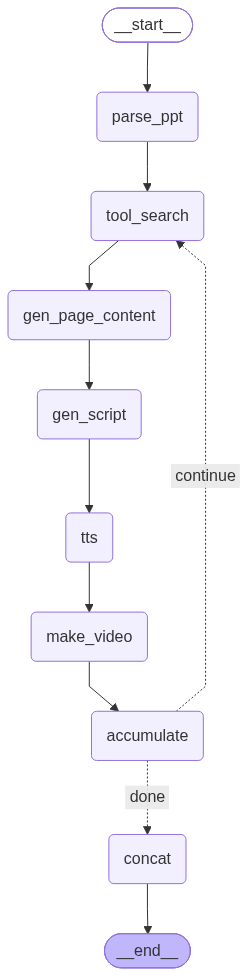

In [21]:
graph_app

## 🚀 Cell 15. 전체 파이프라인 실행 테스트

In [22]:
from pathlib import Path

TEST_PPTX_PATH = "../data/sample.pptx"
base_name = Path(TEST_PPTX_PATH).stem
FINAL_WORK_DIR = f"./output_v3_{base_name}"

initial_state = {
    "pptx_path": TEST_PPTX_PATH,
    "work_dir": FINAL_WORK_DIR,
    "prompt": {
        "tone": "에너지가 넘치고 자신감 있는 1타 강사 톤",
        "style": "딱딱한 설명 대신 쉬운 비유와 실생활 예시를 적극 활용하세요. 매 슬라이드마다 다른 방식으로 시작하고 마무리하세요.",
        "target_duration_sec": 70,
        "voice": "친절한 튜토리얼",
        "speed": 1.15
    },
    "slide_index": 0,
}

print("🚀 전체 파이프라인 실행 시작!")
print("=" * 50)

final_state = None
for output in graph_app.stream(initial_state, {"recursion_limit": 100}):
    for key, value in output.items():
        final_state = value

print("\n" + "=" * 50)
print("🎉 파이프라인 실행 완료!")

if final_state and final_state.get("final_video"):
    print(f"📁 최종 영상: {final_state['final_video']}")
    display(Video(final_state["final_video"], embed=True, width=800))
else:
    print("⚠️ 최종 영상이 생성되지 않았습니다.")

🚀 전체 파이프라인 실행 시작!
총 3장의 슬라이드를 처리합니다.

=== 1번째 슬라이드 처리 중 ===
  → 제목:모델 성능 모니터링, 본문:12, 노트:없음, 표:0, 이미지:1

=== 2번째 슬라이드 처리 중 ===
  → 제목:ML 모델에 영향을 줄 수 있는 요인, 본문:3, 노트:있음, 표:0, 이미지:1

=== 3번째 슬라이드 처리 중 ===
  → 제목:모델 모니터링 아키텍처, 본문:3, 노트:없음, 표:1, 이미지:0

--- Node 2: 외부 검색(tool_search) 실행 ---
  슬라이드 1 | 제목: 모델 성능 모니터링
  생성된 쿼리 2개
  ✅ 검색 완료: 요약 8건, 참조 8건

--- Node 3: 요약 노트 생성(gen_page_content) 실행 ---
  [LLM 요청] 모델: gpt-4o, 이미지: 2장
  ✅ 요약 노트 생성 완료 (386자)

--- Node 4: 강의 스크립트 생성(gen_script) v3 실행 ---


KeyboardInterrupt: 